# 04 — Random Forest Classifier
Train, tune, evaluate, and save the Random Forest model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = joblib.load('../../models/splits.pkl')
le = joblib.load('../../models/label_encoder.pkl')
class_names = le.classes_
os.makedirs('../../outputs/plots', exist_ok=True)
print("Data loaded. Train:", X_train.shape, "| Test:", X_test.shape)

Data loaded. Train: (960, 11) | Test: (240, 11)


In [2]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Training complete.")

Training complete.


In [3]:
# Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
train_acc = accuracy_score(y_train, rf.predict(X_train))
gap = train_acc - acc
print(f"Random Forest Train Accuracy: {train_acc * 100:.2f}%")
print(f"Random Forest Test Accuracy:  {acc * 100:.2f}%")
print(f"Generalization Gap: {gap * 100:.2f}%")
print("Status:", "Potential overfitting" if gap > 0.03 else "No major overfitting signal")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

Random Forest Train Accuracy: 100.00%
Random Forest Test Accuracy:  98.75%
Generalization Gap: 1.25%
Status: No major overfitting signal

Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      0.99      0.98        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



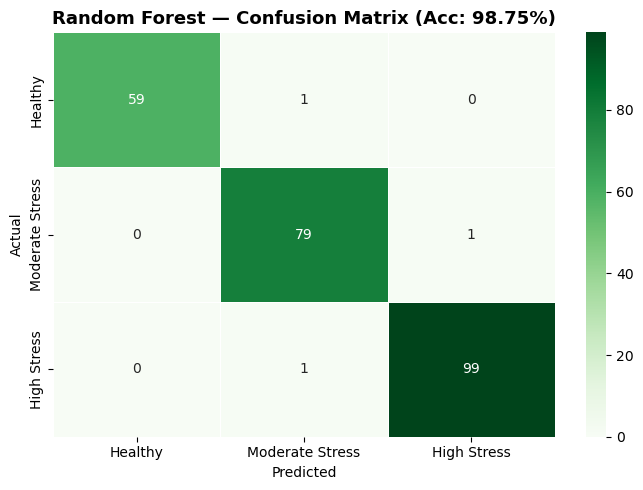

In [4]:
# Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.title(f'Random Forest — Confusion Matrix (Acc: {acc*100:.2f}%)', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../../outputs/plots/confusion_matrix_rf.png', dpi=150)
plt.show()

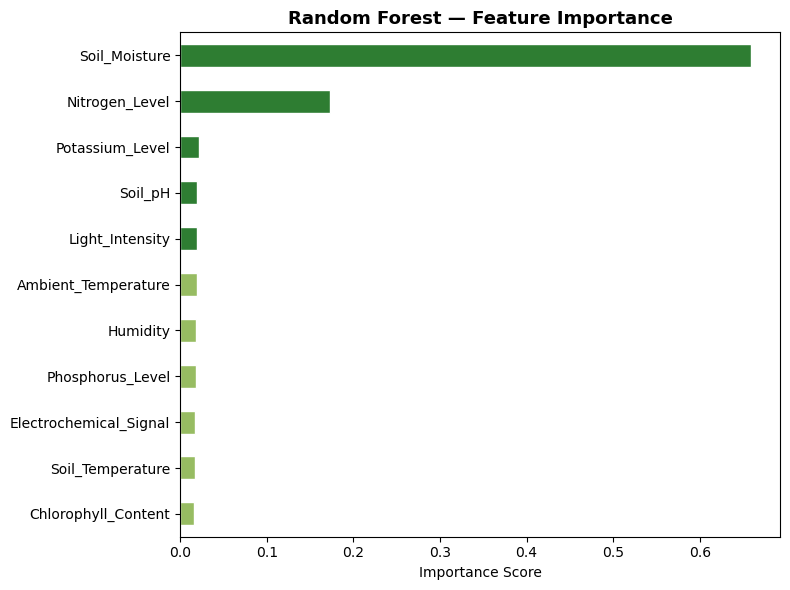

In [5]:
# Feature Importance
from pathlib import Path
raw_path = Path('../../data/plant_health_data.csv')
if not raw_path.exists():
    raw_path = Path('../data/plant_health_data.csv')

df_raw = pd.read_csv(raw_path)
feature_names = df_raw.drop(columns=['Timestamp','Plant_ID','Plant_Health_Status']).columns
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
colors = ['#2E7D32' if v > importances.median() else '#97BC62' for v in importances]
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../../outputs/plots/feature_importance.png', dpi=150)
plt.show()

In [6]:
# Cross-Validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Scores: {cv_scores.round(4)}")
print(f"Mean CV Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

Cross-Validation Scores: [1.     0.9896 1.     0.9948 1.    ]
Mean CV Accuracy: 99.69% ± 0.42%


In [7]:
# Save model
joblib.dump(rf, '../../models/random_forest_model.pkl')
print("Saved: random_forest_model.pkl")

Saved: random_forest_model.pkl
